In [1]:
from dbfread import DBF
import pandas as pd
import numpy as np
import os

from IPython.display import display
import warnings

warnings.filterwarnings('ignore')

## Data preparation

In [2]:
def read_dbf(file_path):
	# read the raw data and store in a dataframe
	dbf = DBF(file_path)
	df = pd.DataFrame(iter(dbf))

	# identify empty strings as missing values
	df.replace("", np.nan, inplace=True)

	# ensure there are now empty rows or columns
	df.dropna(how='all', axis=0, inplace=True)
	df.dropna(how='all', axis=1, inplace=True)

	# remove any duplicates
	df.drop_duplicates(inplace=True)

	# standardize column names
	df.columns = map(lambda x: x.lower(), df.columns)

	return df

### Expedition data

In [3]:
exped_df = read_dbf('data/raw/exped.DBF')

In [4]:
exped_df.shape

(11578, 66)

In [5]:
exped_df.head()

,expid,peakid,year,season,host,route1,route2,route3,route4,nation,...,accidents,achievment,agency,comrte,stdrte,primrte,primmem,primref,primid,chksum
0,ANN260101,ANN2,1960,1,1,NW Ridge-W Ridge,NaN,NaN,NaN,UK,...,NaN,NaN,NaN,None,None,False,False,None,NaN,2442047
1,ANN269301,ANN2,1969,3,1,NW Ridge-W Ridge,NaN,NaN,NaN,Yugoslavia,...,Draslar frostbitten hands and feet,NaN,NaN,None,None,False,False,None,NaN,2445501
2,ANN273101,ANN2,1973,1,1,W Ridge-N Face,NaN,NaN,NaN,Japan,...,NaN,NaN,NaN,None,None,False,False,None,NaN,2446797
3,ANN278301,ANN2,1978,3,1,N Face-W Ridge,NaN,NaN,NaN,UK,...,NaN,NaN,NaN,None,None,False,False,None,NaN,2448822
4,ANN279301,ANN2,1979,3,1,N Face-W Ridge,NW Ridge of A-IV,NaN,NaN,UK,...,NaN,NaN,NaN,None,None,False,False,None,NaN,2449204


In [6]:
exped_df.groupby('expid').expid.count().sort_values(ascending=False)[:1]

expid
KANG10101    2
Name: expid, dtype: int64

In [7]:
exped_df.loc[exped_df.expid == 'KANG10101']

,expid,peakid,year,season,host,route1,route2,route3,route4,nation,...,accidents,achievment,agency,comrte,stdrte,primrte,primmem,primref,primid,chksum
2860,KANG10101,KANG,1910,1,3,NE Side (recon),NaN,NaN,NaN,UK,...,NaN,NaN,NaN,None,None,False,False,None,NaN,2405
6780,KANG10101,KANG,2010,1,1,SW Face,NaN,NaN,NaN,S Korea,...,NaN,NaN,Windhorse Trekking,False,True,False,False,False,NaN,2457821


> Some _expid_ values are duplicated for expeditions to the same peak occuring one century appart

In [8]:
# add the full year to the expedition id to ensure uniqueness
exped_df.expid = exped_df.expid.str.cat(exped_df.year)
assert exped_df.expid.nunique() == exped_df.shape[0]

In [9]:
exped_df.year = exped_df.year.astype(int)

In [10]:
# map country index to name as per the documentation
host_map = {
	0: 'Unknown',
	1: 'Nepal',
	2: 'China',
	3: 'India'
}

exped_df.host = exped_df.host.map(host_map)

In [11]:
# map season index to name as per the documentation
season_map = {
	0: 'Unknown',
	1: 'Spring',
	2: 'Summer',
	3: 'Autumn',
	4: 'Winter'
}

exped_df.season = exped_df.season.map(season_map)

In [12]:
# remove expedition with undefined main route
exped_df = exped_df.loc[exped_df.route1.notna()]

In [13]:
# remove expeditions that include non-climbing activities
exped_df = exped_df.loc[~exped_df.traverse & ~exped_df.ski & ~exped_df.parapente]

exped_df.drop(['traverse', 'ski', 'parapente'], axis=1, inplace=True)

In [14]:
# filter based on expedition termination reason:
# 12 - Did not attempt climb
# 13 - Attempt rumored
exped_df = exped_df.loc[
	~exped_df.termreason.isin([12, 13])
]

exped_df.drop('termreason', axis=1, inplace=True)

In [15]:
# remove unused columns
exped_df.drop([
	'route2', 'route3', 'route4', 'success2', 'success3', 'success4', 'ascent2', 'ascent3', 'ascent4', 'claimed',
	'disputed', 'approach', 'smtdate', 'smttime', 'smtdays', 'totdays', 'termdate', 'termnote', 'highpoint',
	'smtmembers', 'mdeaths', 'smthired', 'hdeaths', 'othersmts', 'campsites', 'routememo', 'accidents', 'achievment',
	'primmem', 'primref', 'primid', 'chksum', 'leaders', 'countries', 'ascent1', 'bcdate', 'o2used', 'o2none',
	'o2medical', 'o2unkwn', 'agency', 'o2taken', 'nohired', 'rope'], axis=1, inplace=True)

In [16]:
exped_df.shape

(10888, 18)

> After initial cleaning and filtering, we are left with a dataset of 10,888 expeditions

In [17]:
# create flag variables to indicate whether the expedition has a sponsor
exped_df['sponsored'] = exped_df.sponsor.notna()
exped_df.drop('sponsor', axis=1, inplace=True)

In [18]:
# concatenate peak and route
exped_df['ascent_route'] = exped_df.peakid.str.cat(exped_df.route1, sep='-').str.replace(" ", "_")
exped_df.drop(['peakid', 'route1'], axis=1, inplace=True)

In [19]:
# find most commonly attempted ascents
route_counts = pd.DataFrame(exped_df.ascent_route.value_counts()).reset_index()
common_routes = route_counts.loc[route_counts['count'] >= 10, 'ascent_route']

In [20]:
# keep only expeditions on common routes
exped_df = exped_df.loc[exped_df.ascent_route.isin(common_routes)]

# keep only recent expeditions
exped_df = exped_df.loc[exped_df.year >= 1980]

In [21]:
exped_df.comrte = exped_df.comrte.fillna(False)
exped_df.stdrte = exped_df.stdrte.fillna(False)

In [22]:
exped_df.shape

(7789, 17)

In [23]:
exped_df.head()

,expid,year,season,host,nation,success1,camps,totmembers,tothired,o2climb,o2descent,o2sleep,comrte,stdrte,primrte,sponsored,ascent_route
35,ANN4811011981,1981,Spring,Nepal,W Germany,True,4,7,3,False,False,False,False,False,False,True,ANN4-NW_Ridge
36,ANN4813011981,1981,Autumn,Nepal,Italy,False,4,19,0,False,False,False,False,False,True,True,ANN4-NW_Ridge
38,ANN4831011983,1983,Spring,Nepal,Japan,True,4,4,1,False,False,False,False,False,False,True,ANN4-NW_Ridge
39,ANN4833011983,1983,Autumn,Nepal,Switzerland,True,3,15,3,False,False,False,False,False,False,True,ANN4-NW_Ridge
40,ANN4843021984,1984,Autumn,Nepal,France,False,3,10,2,False,False,False,False,False,False,True,ANN4-NW_Ridge


In [24]:
exped_df.rename({'success1': 'success'}, axis=1, inplace=True)

### Climber data

In [25]:
climber_df = read_dbf('data/raw/members.DBF')

In [26]:
climber_df.head()

,expid,membid,peakid,myear,mseason,fname,lname,sex,age,yob,...,membermemo,necrology,msmtbid,msmtterm,hcn,mchksum,msmtnote1,msmtnote2,msmtnote3,deathrte
0,AMAD78301,01,AMAD,1978,3,Jean Robert,Clemenson,M,0,1938,...,None,None,1,4,0,2426937,NaN,NaN,NaN,NaN
1,AMAD78301,02,AMAD,1978,3,Bernard,Dufour,M,0,1936,...,None,None,1,4,0,2426501,NaN,NaN,NaN,NaN
2,AMAD78301,03,AMAD,1978,3,Philippe,Gerard,M,0,1950,...,None,None,1,4,0,2431569,NaN,NaN,NaN,NaN
3,AMAD78301,04,AMAD,1978,3,Eric,Lasserre,M,0,1937,...,None,None,1,4,0,2426809,NaN,NaN,NaN,NaN
4,AMAD78301,05,AMAD,1978,3,Guy,Peters,M,0,1944,...,None,None,1,4,0,2429215,NaN,NaN,NaN,NaN


In [27]:
climber_df = climber_df[[
	'expid', 'myear', 'mseason', 'fname', 'lname', 'yob', 'status', 'leader', 'support', 'disabled', 'hired', 'sherpa',
	'msuccess']].dropna(how='any', subset=['expid', 'myear', 'fname', 'lname', 'yob'])

In [28]:
climber_df.dtypes

expid       object
myear       object
mseason      int64
fname       object
lname       object
yob         object
status      object
leader        bool
support       bool
disabled      bool
hired         bool
sherpa        bool
msuccess      bool
dtype: object

In [29]:
climber_df.expid = climber_df.expid.str.cat(climber_df.myear)
climber_df['age'] = climber_df.myear.astype(int) - climber_df.yob.astype(int)

In [30]:
climber_df.sort_values(['fname', 'lname', 'yob', 'myear', 'mseason'], inplace=True)

In [31]:
climber_df['experience'] = climber_df.groupby(['fname', 'lname', 'yob'], as_index=False).expid.cumcount()
climber_df['leadership_experience'] = climber_df.groupby(['fname', 'lname', 'yob'], as_index=False).leader.cumsum()
climber_df['successes'] = climber_df.groupby(['fname', 'lname', 'yob'], as_index=False).msuccess.cumsum()

In [32]:
climber_df.experience = climber_df.experience.map(lambda x: max(x-1, 0))
climber_df.leadership_experience = climber_df.leadership_experience.map(lambda x: max(x-1, 0))
climber_df.successes = climber_df.successes.map(lambda x: max(x-1, 0))

In [33]:
team_df = climber_df.groupby('expid', as_index=False).agg({
	'experience': 'sum',
	'leadership_experience': 'sum',
	'successes': 'sum',
	'age': 'mean',
	'leader': 'sum',
	'support': 'sum',
	'disabled': 'sum',
	'hired': 'sum',
	'sherpa': 'sum'
})

In [34]:
team_df.head()

,expid,experience,leadership_experience,successes,age,leader,support,disabled,hired,sherpa
0,ACHN153012015,0,0,0,22.600000,1,0,0,0,0
1,ACHN153022015,62,43,26,49.181818,1,0,0,2,0
2,ACHN183012018,27,3,10,44.555556,2,0,0,1,0
3,AMAD001012000,0,0,0,31.200000,1,0,0,0,0
4,AMAD001022000,0,0,0,39.000000,1,0,0,0,0


In [35]:
team_df.rename({
	'experience': 'total_experience',
	'leadership_experience': 'total_leadership_experience',
	'successes': 'total_successes',
	'leader': 'leaders',
	'sherpa': 'sherpas',
	'age': 'avg_climber_age'
}, axis=1, inplace=True)

In [36]:
exped_cols = set(exped_df.columns)
team_cols = set(team_df.columns)

In [37]:
team_df.shape

(11434, 10)

In [38]:
df = exped_df.merge(team_df, how='inner')

In [39]:
# verify that there is still exactly one row per expedition
assert df.expid.nunique() == df.shape[0]

In [40]:
df.shape

(7766, 26)

In [41]:
df.head()

,expid,year,season,host,nation,success,camps,totmembers,tothired,o2climb,...,ascent_route,total_experience,total_leadership_experience,total_successes,avg_climber_age,leaders,support,disabled,hired,sherpas
0,ANN4811011981,1981,Spring,Nepal,W Germany,True,4,7,3,False,...,ANN4-NW_Ridge,3,1,4,34.750000,1,0,0,1,1
1,ANN4813011981,1981,Autumn,Nepal,Italy,False,4,19,0,False,...,ANN4-NW_Ridge,7,2,0,38.157895,1,0,0,0,0
2,ANN4831011983,1983,Spring,Nepal,Japan,True,4,4,1,False,...,ANN4-NW_Ridge,5,0,3,31.400000,1,0,0,1,0
3,ANN4833011983,1983,Autumn,Nepal,Switzerland,True,3,15,3,False,...,ANN4-NW_Ridge,5,0,1,41.411765,1,0,0,2,1
4,ANN4843021984,1984,Autumn,Nepal,France,False,3,10,2,False,...,ANN4-NW_Ridge,0,0,0,37.900000,1,0,0,0,0


In [42]:
if not os.path.exists('./data/processed'):
	os.mkdir('./data/processed')

df.to_csv('./data/processed/expeditions.csv', index=False)

## Exploratory data analysis

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# overall success rate
(df.success.value_counts() / df.shape[0]).round(2)

success
True     0.62
False    0.38
Name: count, dtype: float64

> The target variable - team expedition success - is slightly skewed towards the positive

### Plots
#### Expeditions by year

In [45]:
yearly_df = df.groupby('year', as_index=False)\
	.agg({'expid': 'nunique', 'success': 'mean'})\
	.sort_values('year')\
	.rename({'success': 'success_rate'}, axis=1)

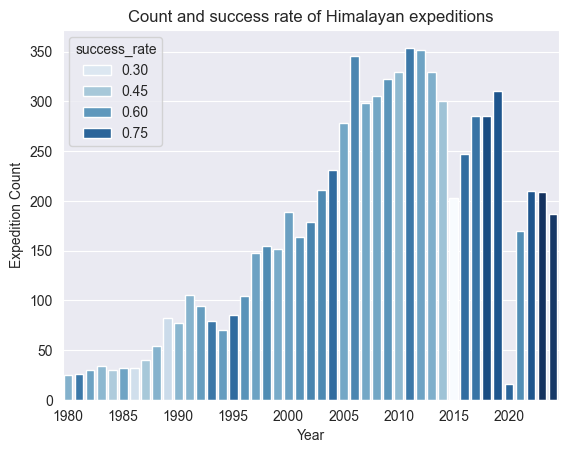

In [46]:
sns.barplot(data=yearly_df, x='year', y='expid', hue='success_rate', palette='Blues')
plt.title('Count and success rate of Himalayan expeditions')
plt.xlabel('Year')

# Show only every 5th xtick
ticks = plt.xticks()[0]          # current tick positions
plt.xticks(ticks[::5])

plt.ylabel('Expedition Count')
plt.show()

> The number of expeditions peaked in 2011 and has been declining since.
> The success rate of expeditions increased significantly after 2015 (no data for 2015, presumably due to Nepal earthquake)

### Expeditions by route

In [47]:
most_common_routes = df.groupby('ascent_route').expid.nunique().sort_values(ascending=False)[:20].index
routes_df = df.loc[df.ascent_route.isin(most_common_routes)]

In [48]:
routes_df = routes_df.groupby('ascent_route', as_index=False)\
	.agg({'expid': 'nunique', 'success': 'mean'})\
	.rename({'success': 'success_rate'}, axis=1)\
	.sort_values('expid', ascending=False)

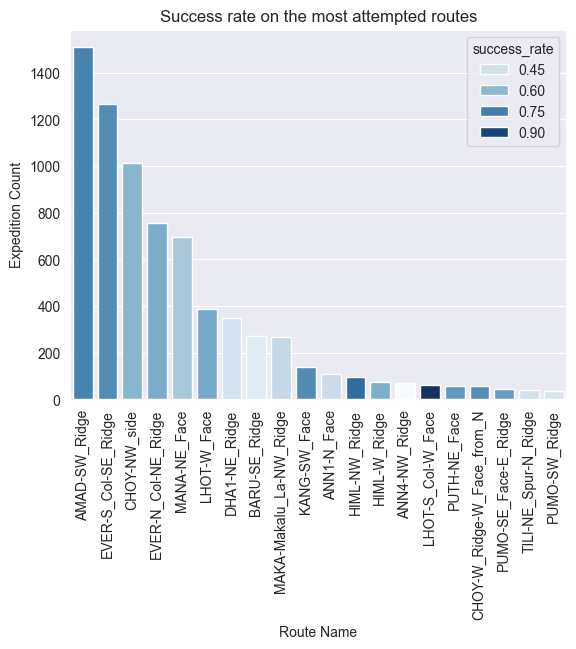

In [49]:
sns.barplot(data=routes_df, x='ascent_route', y='expid', hue='success_rate', palette='Blues')
plt.title('Success rate on the most attempted routes')
plt.xlabel('Route Name')
plt.xticks(rotation=90)

plt.ylabel('Expedition Count')
plt.show()

> Success rates on the most commonly attempted routes vary between 45% and 90%

### Team stats
#### Member age distribution

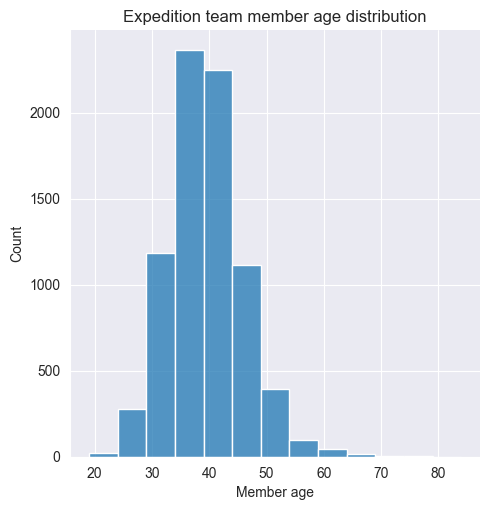

In [50]:
sns.displot(df, x="avg_climber_age", binwidth=5)
plt.title('Expedition team member age distribution')
plt.xlabel('Member age')
plt.show()

> At expedition start, most team members are in the 35-45 age range

#### Average age and success rate

In [51]:
# Create bins
age_df = df[['avg_climber_age', 'success']].copy()
age_df['age_bin'] = pd.cut(age_df['avg_climber_age'], 20) # create bins for the

In [52]:
age_df = age_df.groupby('age_bin', as_index=False).success.mean()

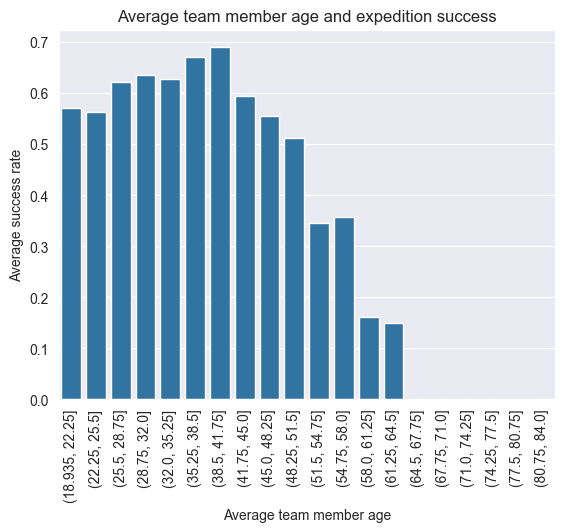

In [53]:
sns.barplot(data=age_df, x='age_bin', y='success')
plt.title('Average team member age and expedition success')
plt.xlabel('Average team member age')
plt.ylabel('Average success rate')
plt.xticks(rotation=90)
plt.show()

> Expedition teams with an average age in the late 30s have the highest success rate (near 70%)

#### Member experience and success rate

In [54]:
df.total_experience.describe()

count    7766.000000
mean       23.346124
std        38.745126
min         0.000000
25%         2.000000
50%         9.000000
75%        27.000000
max       541.000000
Name: total_experience, dtype: float64

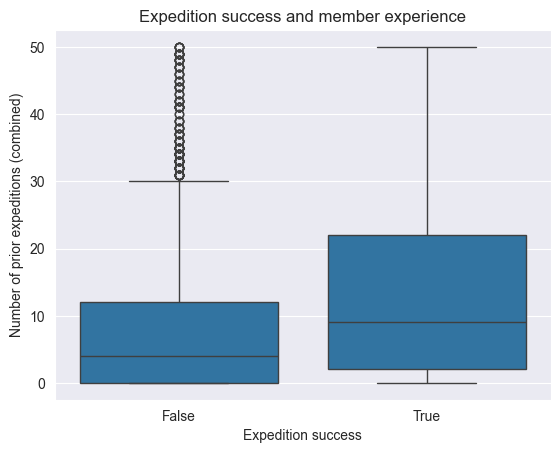

In [55]:
sns.boxplot(data=df.loc[df.total_experience <= 50], x='success', y='total_experience')
plt.title('Expedition success and member experience')
plt.xlabel('Expedition success')
plt.ylabel('Number of prior expeditions (combined)')
plt.show()

In [56]:
df.groupby('success').agg({'total_experience': ['mean', 'std']}).round(2)

total_experience       
                    mean    std
success                        
False              12.27  23.00
True               30.12  44.44

> Teams that succeeded in their expedition started with a higher amount of experience among its team members

### Feature Importance
#### Success ratio
> Feature importance is evaluated by observing average success rate across categories for each discrete variable. Variables that show high variance in success rate across categories can be assumed to have more predictive power.

In [57]:
df.success = df.success.astype(int)
global_success_rate = df.success.mean()

In [58]:
categorical = df.drop(['expid', 'success'], axis=1).select_dtypes(exclude='number').columns
numerical = df.drop(['expid', 'success'], axis=1).select_dtypes('number').columns

In [59]:
for c in categorical:
    print(c.upper())
    df_group = df.groupby(c).success.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_success_rate
    df_group['probability'] = df_group['mean'] / global_success_rate
    display(df_group)
    print()

SEASON


,mean,count,diff,probability
season,,,,
Autumn,0.628279,3621,0.007754,1.012496
Spring,0.623413,3938,0.002888,1.004653
Summer,0.285714,21,-0.334811,0.460439
Winter,0.446237,186,-0.174289,0.719127



HOST


,mean,count,diff,probability
host,,,,
China,0.617538,1893,-0.002987,0.995186
Nepal,0.621530,5871,0.001004,1.001618
Unknown,0.500000,2,-0.120525,0.805769



NATION


...

,mean,count,diff,probability
primrte,,,,
False,0.620310,7730,-0.000215,0.999654
True,0.666667,36,0.046141,1.074358



SPONSORED


,mean,count,diff,probability
sponsored,,,,
False,0.555556,324,-0.064970,0.895299
True,0.623354,7442,0.002829,1.004558



ASCENT_ROUTE


,mean,count,diff,probability
ascent_route,,,,
AMAD-N_Ridge,0.333333,15,-0.287192,0.537179
AMAD-SW_Ridge,0.739735,1510,0.119210,1.192111
ANN1-N_Face,0.472727,110,-0.147798,0.761818
ANN1-N_Face_(Dutch_Rib),0.235294,17,-0.385231,0.379185
ANN1-S_Face,0.227273,22,-0.393253,0.366259
ANN4-NW_Ridge,0.314286,70,-0.306240,0.506483
BARU-SE_Ridge,0.393382,272,-0.227143,0.633950
CHOY-NW_side,0.602767,1012,-0.017759,0.971381
CHOY-NW_side_(direct_rte),0.900000,10,0.279475,1.450384


> * Winter/Summer expeditions are less frequent and less successful
> * Usage of oxygen is correlated with a higher success rate
> * Success rates across routes vary significantly

#### Mutual information

In [60]:
from sklearn.metrics import mutual_info_score

In [61]:
def mutual_info_churn_score(series):
	return mutual_info_score(series, df.success)

In [62]:
mi = df[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

o2climb         0.070938
ascent_route    0.041648
o2sleep         0.031718
nation          0.023161
comrte          0.010501
season          0.002180
o2descent       0.000698
sponsored       0.000383
primrte         0.000021
host            0.000014
stdrte          0.000006
dtype: float64

#### Correlation
> Correlation allows us to evaluate how the numerical variables in our dataset fluctuate with success. This will show us the variables whose relatively higher/lower values are more often associated with a successful expedition.

In [63]:
df[numerical].corrwith(df.success).sort_values(ascending=False)

camps                          0.300740
total_successes                0.261589
sherpas                        0.256398
hired                          0.255790
total_experience               0.223559
tothired                       0.197454
totmembers                     0.180974
year                           0.114152
total_leadership_experience    0.094977
support                        0.017193
disabled                       0.017064
leaders                       -0.006144
avg_climber_age               -0.115256
dtype: float64

> All numerical variables in the dataset are positively correlated with expedition success

## Model development
### Feature transformation

In [64]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split

In [65]:
df['failure'] = 1 - df.success
df = df.drop(['expid', 'success'], axis=1).reset_index(drop=True)

In [66]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1, stratify=df.failure)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1, stratify=df_full_train.failure)

In [67]:
def one_hot_encoding(df, dv=None):
	df_dicts = df.to_dict(orient='records')

	if not dv:
		dv = DictVectorizer(sparse=False)
		dv.fit(df_dicts)

	X = pd.DataFrame(
		data=dv.transform(df_dicts),
		columns=dv.get_feature_names_out()
	)

	return X, dv

In [68]:
X_train, dv = one_hot_encoding(df_train)
X_val, _ = one_hot_encoding(df_val, dv=dv)
X_test, _ = one_hot_encoding(df_test, dv=dv)

In [69]:
y_train = X_train.failure
y_val = X_val.failure
y_test = X_test.failure

X_train.drop('failure', axis=1, inplace=True)
X_val.drop('failure', axis=1, inplace=True)
X_test.drop('failure', axis=1, inplace=True)

### Model Training & evaluation

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import NMF, PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix
import re

In [71]:
N_FEATURES_OPTIONS = [2, 4, 8, 20, 50, 100, None]
C_OPTIONS = [0.01, 0.1, 1, 10]

In [72]:
def hyperparameter_tuning_cv(model, model_params, X, y):
	pipe = Pipeline(
		[
			("scaling", MinMaxScaler()),
			# the reduce_dim stage is populated by the param_grid
			("reduce_dim", "passthrough"),
			("classify", model),
    ]
	)

	params_1 = {
		"reduce_dim": [PCA(iterated_power=7)],
		"reduce_dim__n_components": N_FEATURES_OPTIONS,
  }

	params_2 = {
		"reduce_dim": [SelectKBest(mutual_info_classif)],
    "reduce_dim__k": N_FEATURES_OPTIONS,
  }

	params_1.update(model_params)
	params_2.update(model_params)

	param_grid = [params_1, params_2]

	cv = KFold(n_splits=5, shuffle=True, random_state=42)
	grid = GridSearchCV(pipe, n_jobs=-1, param_grid=param_grid, cv=cv, scoring='recall')
	grid.fit(X, y)

	return grid

#### Logistic regression

In [73]:
lr = LogisticRegression(solver='liblinear', max_iter=10000, random_state=42)
lr_params = {
	"classify__C": C_OPTIONS,
	"classify__penalty": ["l1", "l2"]
}

lr_grid = hyperparameter_tuning_cv(lr, lr_params, X_train, y_train)

In [89]:
lr_results = pd.DataFrame(lr_grid.cv_results_)
lr_results['model'] = 'Logistic Regression'

#### Support vector machine

In [74]:
svm = LinearSVC(dual=False, max_iter=10000, random_state=42)
svm_params = {
	"classify__C": C_OPTIONS,
	"classify__penalty": ["l1", "l2"]
}

svm_grid = hyperparameter_tuning_cv(svm, svm_params, X_train, y_train)

In [90]:
svm_results = pd.DataFrame(svm_grid.cv_results_)
svm_results['model'] = 'Support Vector Machine'

#### Decision tree

In [75]:
dt = DecisionTreeClassifier(random_state=42)
dt_params = {
	"classify__max_depth": [2, 8, 20, 50, 100, None],
	"classify__min_samples_leaf": [1, 5, 10]
}

dt_grid = hyperparameter_tuning_cv(dt, dt_params, X_train, y_train)

In [91]:
dt_results = pd.DataFrame(dt_grid.cv_results_)
dt_results['model'] = 'Decision Tree'

#### Compare models

In [103]:
mean_scores = pd.concat(
	[
		lr_results[['model', 'mean_test_score', 'std_test_score']],
		svm_results[['model', 'mean_test_score', 'std_test_score']],
		dt_results[['model', 'mean_test_score', 'std_test_score']]
	], ignore_index=True).dropna(how='all')

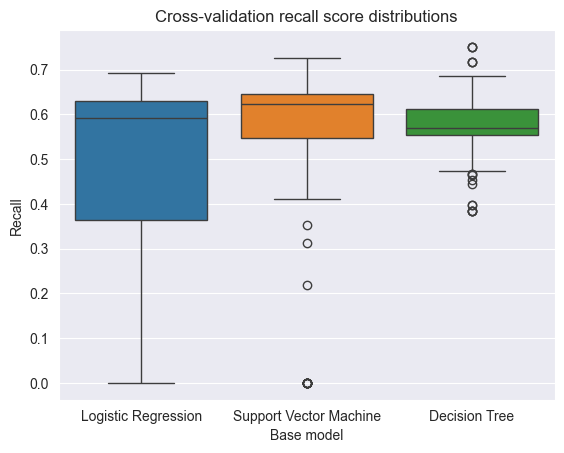

In [170]:
sns.boxplot(data=mean_scores, x='model', y='mean_test_score', hue='model')
plt.title('Cross-validation recall score distributions')
plt.xlabel('Base model')
plt.ylabel('Recall')
plt.show()

In [178]:
split_scores = pd.concat([lr_results, svm_results, dt_results], ignore_index=True)
split_scores = split_scores.melt(
	id_vars='model',
	value_vars=[col for col in split_scores.columns if col.startswith('split')],
	var_name='split',
	value_name='score'
)

split_scores.split = split_scores.split.apply(lambda x: re.search(r"\d", x).group())

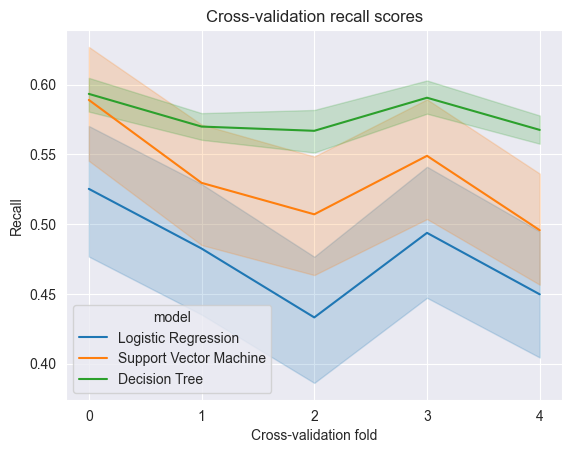

In [188]:
sns.lineplot(data=split_scores, x='split', y='score', hue='model')
plt.title('Cross-validation recall scores')
plt.xlabel('Cross-validation fold')
plt.ylabel('Recall')
plt.show()

In [201]:
best_scores = {
	'Logistic Regression': lr_grid.best_score_,
	'Support Vector Machine': svm_grid.best_score_,
	'Decision Tree': dt_grid.best_score_
}

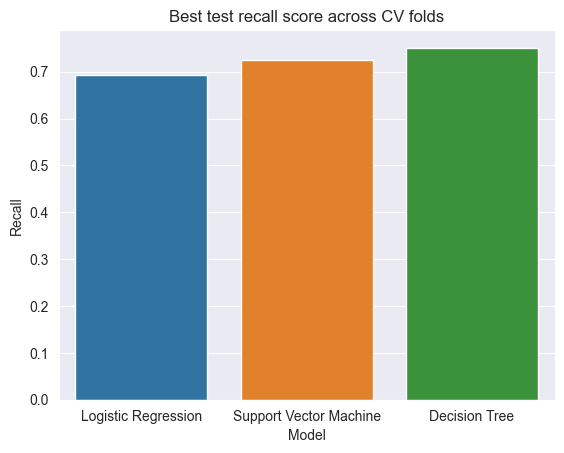

In [212]:
sns.barplot(
	x=best_scores.keys(),
	y=best_scores.values(),
	hue=best_scores.keys()
)

plt.title('Best test recall score across CV folds')
plt.xlabel('Model')
plt.ylabel('Recall')
plt.show()